<a href="https://colab.research.google.com/github/Mubby03/Machine-Deep-Learning-Pancakes/blob/main/DiabetesExcercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("excercise diabetes")

excercise diabetes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


In [ ]:
diabetes = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
diabetes.head(5)
diabetes.dtypes
diabetes.columns
diabetes.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Create a copy so original stays untouched
diabetesNew = diabetes.copy()

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    diabetesNew[col] = diabetesNew[col].replace(0, np.nan)
    diabetesNew[col] = diabetesNew[col].fillna(diabetesNew[col].mean())

# result
print(diabetesNew.isnull().sum())
diabetesNew.iloc[5:11]


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
5,5,116.0,74.000000,29.15342,155.548223,25.600000,0.201,30,0
6,3,78.0,50.000000,32.00000,88.000000,31.000000,0.248,26,1
7,10,115.0,72.405184,29.15342,155.548223,35.300000,0.134,29,0
8,2,197.0,70.000000,45.00000,543.000000,30.500000,0.158,53,1
9,8,125.0,96.000000,29.15342,155.548223,32.457464,0.232,54,1
10,4,110.0,92.000000,29.15342,155.548223,37.600000,0.191,30,0


In [ ]:
diabetesNew.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

<Axes: >

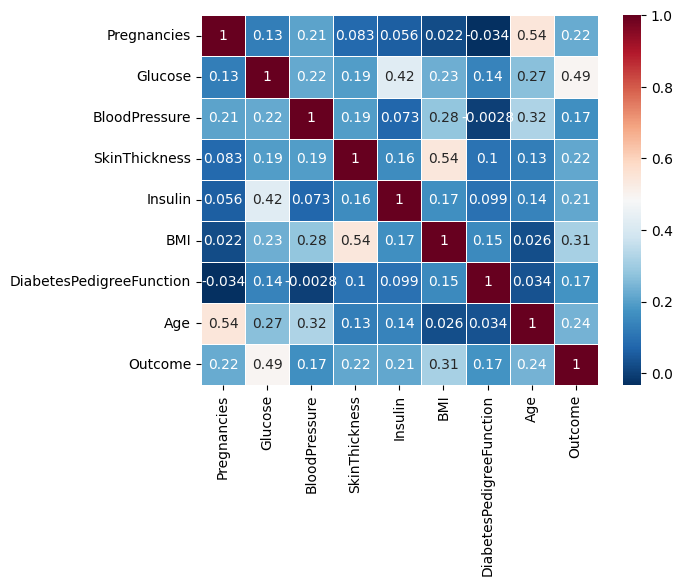

In [ ]:
pearsoncorr=diabetesNew.corr(method='pearson',numeric_only=True)
import seaborn as sb
sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

In [ ]:
X = diabetesNew.drop('Outcome', axis=1)
print('The values of the inputs are :',X)
y = diabetesNew['Outcome']
print('The values of target are :',y)

The values of the inputs are :      Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0              6    148.0           72.0       35.00000  155.548223  33.6   
1              1     85.0           66.0       29.00000  155.548223  26.6   
2              8    183.0           64.0       29.15342  155.548223  23.3   
3              1     89.0           66.0       23.00000   94.000000  28.1   
4              0    137.0           40.0       35.00000  168.000000  43.1   
..           ...      ...            ...            ...         ...   ...   
763           10    101.0           76.0       48.00000  180.000000  32.9   
764            2    122.0           70.0       27.00000  155.548223  36.8   
765            5    121.0           72.0       23.00000  112.000000  26.2   
766            1    126.0           60.0       29.15342  155.548223  30.1   
767            1     93.0           70.0       31.00000  155.548223  30.4   

     DiabetesPedigreeFunction  Age  
0      

In [ ]:
X_train, X_test, Y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0)
print("X_train Shape : ", X_train.shape)
print("X_test Shape  : ", X_test.shape)
print("y_train Shape : ", Y_train.shape)
print("y_test Shape  : ", y_test.shape)

X_train Shape :  (614, 8)
X_test Shape  :  (154, 8)
y_train Shape :  (614,)
y_test Shape  :  (154,)


In [ ]:
# Normalization (MinMax)
# min_max_scaler = preprocessing.MinMaxScaler()
# X_train=min_max_scaler.fit_transform(X_train)
# X_test=min_max_scaler.transform(X_test)

# Standardization (Standard Scalar)
scaled = StandardScaler()
X_train= scaled.fit_transform(X_train)
X_test = scaled.transform(X_test)

[[97 10]
 [19 28]]


<Axes: >

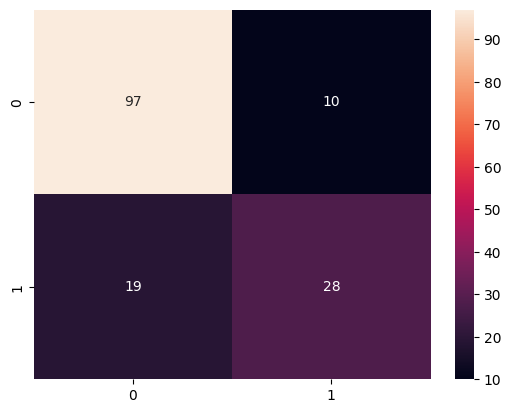

In [ ]:
# Logistic Regression (Standardaized)

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

ylrpredicted=lr.predict(X_test)
cmLR = confusion_matrix(y_test, ylrpredicted)
print(cmLR)
sns.heatmap(cmLR, annot=True)

In [ ]:
print(classification_report(y_test, ylrpredicted))
print("Accuracy:", accuracy_score(y_test, ylrpredicted))
print("F1_score:",f1_score(y_test, ylrpredicted, average='weighted'))
F1_LogisticRegression=f1_score(y_test, ylrpredicted, average='weighted')

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       107
           1       0.74      0.60      0.66        47

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.81      0.81      0.81       154

Accuracy: 0.8116883116883117
F1_score: 0.8055188810134735


[[93 14]
 [16 31]]


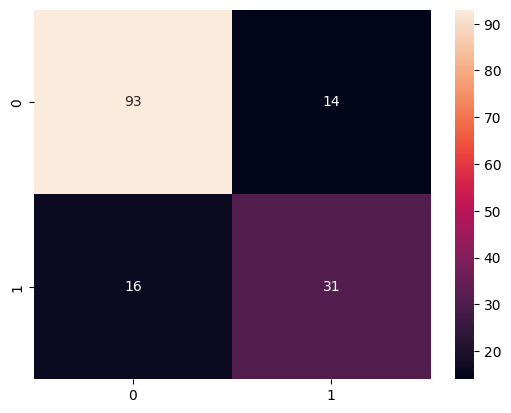

In [132]:
# Random Forest (Standardaized)

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, Y_train)

# Predict and check the matrix
yrf_predicted = rf.predict(X_test)
cmRF = confusion_matrix(y_test, yrf_predicted)
sns.heatmap(cmRF, annot=True)
# print(cm)
print(confusion_matrix(y_test, yrf_predicted))

In [ ]:
print(classification_report(y_test, yrf_predicted))
print("Accuracy:", accuracy_score(y_test, yrf_predicted))
print("F1_score:",f1_score(y_test, yrf_predicted, average='weighted'))
F1_RandomForest=f1_score(y_test, yrf_predicted, average='weighted')

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154

Accuracy: 0.8051948051948052
F1_score: 0.8039792333270596


In [ ]:
# SVM Model (Standardaized)

svm = SVC(kernel='poly')
# svm=SVC(kernel='rbf')#default
# svm = SVC(kernel='linear')
svm.fit(X_train, Y_train)

SVC(kernel='poly')

[[96 11]
 [30 17]]


<Axes: >

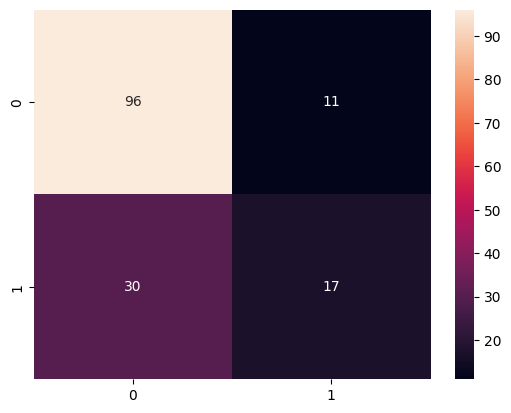

In [ ]:
ysvmpredicted=svm.predict(X_test)
cmSVM=confusion_matrix(y_test,ysvmpredicted)
print(cmSVM)

sns.heatmap(cmSVM, annot=True)

In [ ]:
print(classification_report(y_test, ysvmpredicted))
print("Accuracy:", accuracy_score(y_test, ysvmpredicted))
print("F1_score:",f1_score(y_test, ysvmpredicted, average='weighted'))
F1_svm=f1_score(y_test, ysvmpredicted, average='weighted')

              precision    recall  f1-score   support

           0       0.76      0.90      0.82       107
           1       0.61      0.36      0.45        47

    accuracy                           0.73       154
   macro avg       0.68      0.63      0.64       154
weighted avg       0.71      0.73      0.71       154

Accuracy: 0.7337662337662337
F1_score: 0.7108983148468128


[[97 10]
 [19 28]]


<Axes: >

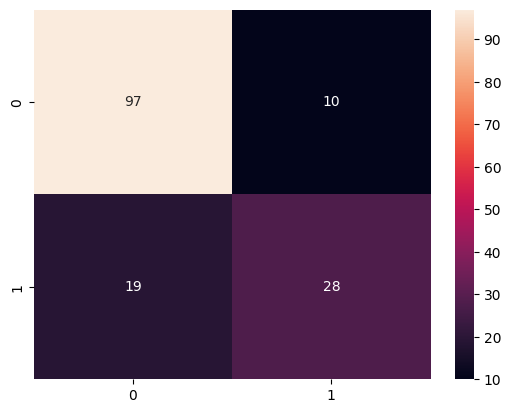

In [ ]:
# KNN (Standardaized)

k=14

KNN = KNeighborsClassifier(n_neighbors =14)

KNN.fit(X_train, Y_train)

yknnpredicted = KNN.predict(X_test)

cmKNN=confusion_matrix(y_test,yknnpredicted)

print(cmKNN)

sns.heatmap(cmKNN, annot=True)

In [ ]:
print(classification_report(y_test, yknnpredicted))
print("Accuracy:", accuracy_score(y_test, yknnpredicted))
print("F1_score:",f1_score(y_test, yknnpredicted, average='weighted'))
F1_KNN=f1_score(y_test, yknnpredicted, average='weighted')

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       107
           1       0.74      0.60      0.66        47

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.81      0.81      0.81       154

Accuracy: 0.8116883116883117
F1_score: 0.8055188810134735


In [ ]:
# Decision tree (Standardaized)

tree = DecisionTreeClassifier()
#tree = DecisionTreeClassifier(max_depth=5,criterion="entropy")
tree.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
ytreepredicted = tree.predict(X_test)
cm=confusion_matrix(y_test,ytreepredicted)
print(cm)

[[82 25]
 [19 28]]


<Axes: >

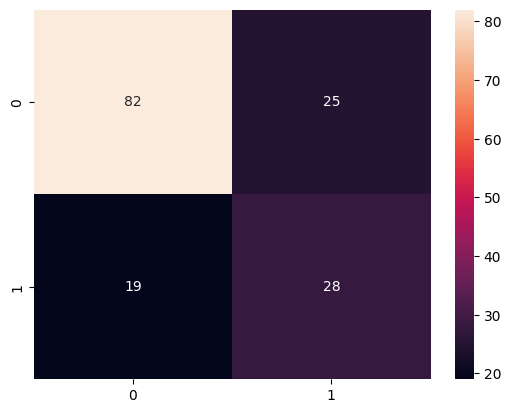

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True)

In [ ]:
print(classification_report(y_test, ytreepredicted))
print("Accuracy:", accuracy_score(y_test, ytreepredicted))
print("F1_score:",f1_score(y_test, ytreepredicted, average='weighted'))
F1_tree=f1_score(y_test, ytreepredicted, average='weighted')

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       107
           1       0.53      0.60      0.56        47

    accuracy                           0.71       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.73      0.71      0.72       154

Accuracy: 0.7142857142857143
F1_score: 0.7187362637362638


In [ ]:
# Gradient boosting (Standardaized)

GB= GradientBoostingClassifier()
GB.fit(X_train, Y_train)

GradientBoostingClassifier()

[[91 16]
 [15 32]]


<Axes: >

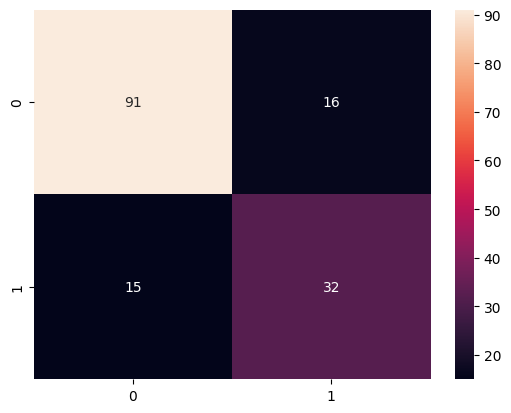

In [ ]:
yGBpredicted=GB.predict(X_test)
cm=confusion_matrix(y_test,yGBpredicted)
print(cm)
sns.heatmap(cm, annot=True)

In [ ]:
print(classification_report(y_test, yGBpredicted))
print("Accuracy:", accuracy_score(y_test, yGBpredicted))
print("F1_score:",f1_score(y_test, yGBpredicted, average='weighted'))
F1_GB=f1_score(y_test, yGBpredicted, average='weighted')

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       107
           1       0.67      0.68      0.67        47

    accuracy                           0.80       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.80      0.80      0.80       154

Accuracy: 0.7987012987012987
F1_score: 0.7992882333875662


In [ ]:
models = ['Logistic Regression', 'SVM','Decision Tree','KNN','Random Forest','Gradient boosted tree']
F1_score = [F1_LogisticRegression, F1_svm, F1_tree, F1_KNN, F1_RandomForest, F1_GB]
compare_models = pd.DataFrame({ 'Algorithms': models, 'F1 Score (Standard Scaled)': F1_score })
compare_models.sort_values(by = 'F1 Score (Standard Scaled)', ascending = False)

,Algorithms,F1 Score (Standard Scaled)
0,Logistic Regression,0.805519
3,KNN,0.805519
4,Random Forest,0.803979
5,Gradient boosted tree,0.799288
2,Decision Tree,0.718736
1,SVM,0.710898


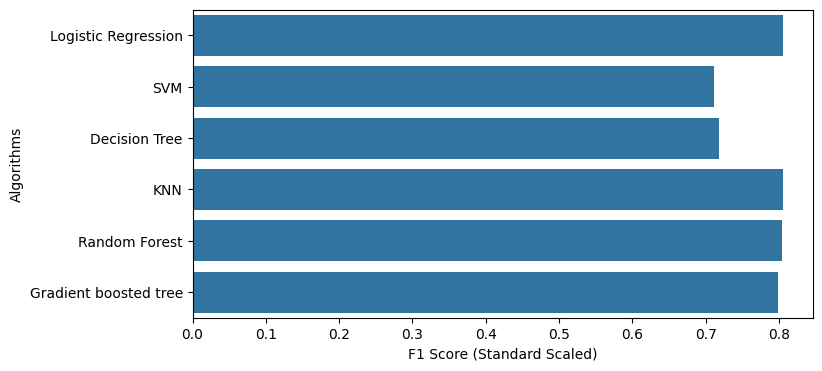

In [ ]:
plt.figure(figsize=(8,4))
TestsScore=F1_score
sns.barplot(x = 'F1 Score (Standard Scaled)', y = 'Algorithms', data = compare_models)
plt.show()

Let's now use normalization instead of standard scalar.

In [ ]:
# Normalization (MinMax)
min_max_scaler = preprocessing.MinMaxScaler()
X_train=min_max_scaler.fit_transform(X_train)
X_test=min_max_scaler.transform(X_test)

Confusion Matrix (Logistic Regression with Normalization):
[[97 10]
 [20 27]]


<Axes: >

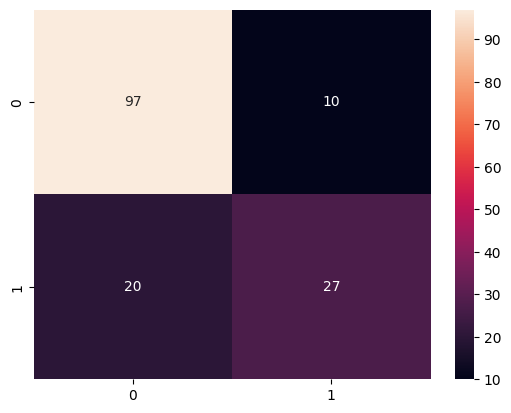

In [ ]:
# Logistic regression Normalizeds

lr_norm = LogisticRegression(max_iter=1000)
lr_norm.fit(X_train, Y_train)

ylrpredicted_norm = lr_norm.predict(X_test)

cmLR_norm = confusion_matrix(y_test, ylrpredicted_norm)
print('Confusion Matrix (Logistic Regression with Normalization):')
print(cmLR_norm)
sns.heatmap(cmLR_norm, annot=True)

In [ ]:
print('\nClassification Report (Logistic Regression with Normalization):')
print(classification_report(y_test, ylrpredicted_norm))

print('\nAccuracy (Logistic Regression with Normalization):', accuracy_score(y_test, ylrpredicted_norm))

F1_LogisticRegression_norm = f1_score(y_test, ylrpredicted_norm, average='weighted')
print('F1_score (Logistic Regression with Normalization):', F1_LogisticRegression_norm)


Classification Report (Logistic Regression with Normalization):
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       107
           1       0.73      0.57      0.64        47

    accuracy                           0.81       154
   macro avg       0.78      0.74      0.75       154
weighted avg       0.80      0.81      0.80       154


Accuracy (Logistic Regression with Normalization): 0.8051948051948052
F1_score (Logistic Regression with Normalization): 0.7979475881261596


Confusion Matrix (Random Forest with Normalization):
[[93 14]
 [16 31]]


<Axes: >

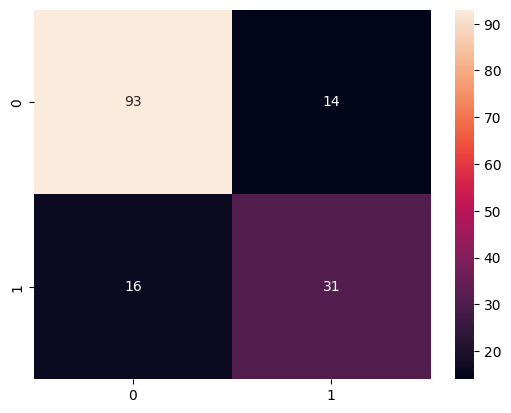

In [ ]:
# Random forest normalized

rf_norm = RandomForestClassifier(n_estimators=100, random_state=0)
rf_norm.fit(X_train, Y_train)

yrf_predicted_norm = rf_norm.predict(X_test)

cmRF_norm = confusion_matrix(y_test, yrf_predicted_norm)
print('Confusion Matrix (Random Forest with Normalization):')
print(cmRF_norm)
sns.heatmap(cmRF_norm, annot=True)



In [ ]:
print('\nClassification Report (Random Forest with Normalization):')
print(classification_report(y_test, yrf_predicted_norm))

print('\nAccuracy (Random Forest with Normalization):', accuracy_score(y_test, yrf_predicted_norm))
F1_RandomForest_norm = f1_score(y_test, yrf_predicted_norm, average='weighted')
print('F1_score (Random Forest with Normalization):', F1_RandomForest_norm)


Classification Report (Random Forest with Normalization):
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154


Accuracy (Random Forest with Normalization): 0.8051948051948052
F1_score (Random Forest with Normalization): 0.8039792333270596


Confusion Matrix (SVM with Normalization):
[[97 10]
 [22 25]]


<Axes: >

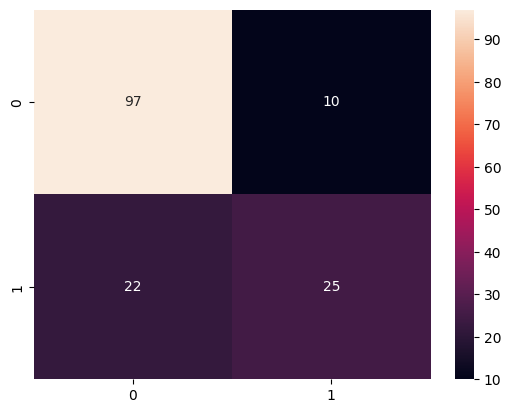

In [ ]:
# SVM normalized

svm_norm = SVC(kernel='poly') # Using 'poly' kernel as in the previous SVM run
svm_norm.fit(X_train, Y_train)

ysvmpredicted_norm = svm_norm.predict(X_test)

cmSVM_norm = confusion_matrix(y_test, ysvmpredicted_norm)
print('Confusion Matrix (SVM with Normalization):')
print(cmSVM_norm)
sns.heatmap(cmSVM_norm, annot=True)


In [ ]:

print('\nClassification Report (SVM with Normalization):')
print(classification_report(y_test, ysvmpredicted_norm))

print('\nAccuracy (SVM with Normalization):', accuracy_score(y_test, ysvmpredicted_norm))
F1_svm_norm = f1_score(y_test, ysvmpredicted_norm, average='weighted')
print('F1_score (SVM with Normalization):', F1_svm_norm)


Classification Report (SVM with Normalization):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       107
           1       0.71      0.53      0.61        47

    accuracy                           0.79       154
   macro avg       0.76      0.72      0.73       154
weighted avg       0.78      0.79      0.78       154


Accuracy (SVM with Normalization): 0.7922077922077922
F1_score (SVM with Normalization): 0.7825200916070763


Confusion Matrix (KNN with Normalization):
[[97 10]
 [20 27]]


<Axes: >

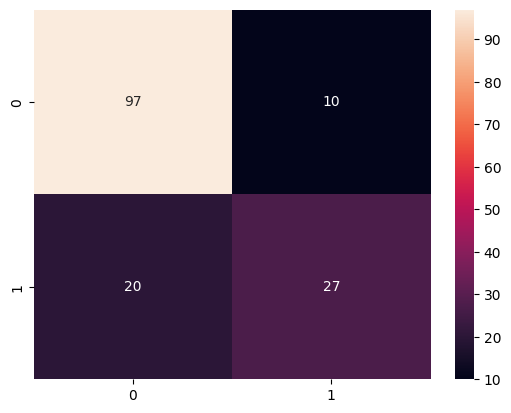

In [ ]:
# KNN normalized
knn_norm = KNeighborsClassifier(n_neighbors=14) # Using k=14 as in the previous KNN run
knn_norm.fit(X_train, Y_train)

yknnpredicted_norm = knn_norm.predict(X_test)

cmKNN_norm = confusion_matrix(y_test, yknnpredicted_norm)
print('Confusion Matrix (KNN with Normalization):')
print(cmKNN_norm)
sns.heatmap(cmKNN_norm, annot=True)



In [ ]:
print('\nClassification Report (KNN with Normalization):')
print(classification_report(y_test, yknnpredicted_norm))

print('\nAccuracy (KNN with Normalization):', accuracy_score(y_test, yknnpredicted_norm))
F1_KNN_norm = f1_score(y_test, yknnpredicted_norm, average='weighted')
print('F1_score (KNN with Normalization):', F1_KNN_norm)


Classification Report (KNN with Normalization):
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       107
           1       0.73      0.57      0.64        47

    accuracy                           0.81       154
   macro avg       0.78      0.74      0.75       154
weighted avg       0.80      0.81      0.80       154


Accuracy (KNN with Normalization): 0.8051948051948052
F1_score (KNN with Normalization): 0.7979475881261596


In [ ]:
# decision tree

tree_norm = DecisionTreeClassifier()
tree_norm.fit(X_train, Y_train)

ytreepredicted_norm = tree_norm.predict(X_test)

cmTree_norm = confusion_matrix(y_test, ytreepredicted_norm)
print('Confusion Matrix (Decision Tree with Normalization):')
print(cmTree_norm)
sns.heatmap(cmTree_norm, annot=True)



Confusion Matrix (Decision Tree with Normalization):
[[84 23]
 [21 26]]

Classification Report (Decision Tree with Normalization):
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       107
           1       0.53      0.55      0.54        47

    accuracy                           0.71       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.72      0.71      0.72       154


Accuracy (Decision Tree with Normalization): 0.7142857142857143
F1_score (Decision Tree with Normalization): 0.715914195867026


In [ ]:
print('\nClassification Report (Decision Tree with Normalization):')
print(classification_report(y_test, ytreepredicted_norm))

print('\nAccuracy (Decision Tree with Normalization):', accuracy_score(y_test, ytreepredicted_norm))
F1_tree_norm = f1_score(y_test, ytreepredicted_norm, average='weighted')
print('F1_score (Decision Tree with Normalization):', F1_tree_norm)


Classification Report (Decision Tree with Normalization):
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       107
           1       0.53      0.55      0.54        47

    accuracy                           0.71       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.72      0.71      0.72       154


Accuracy (Decision Tree with Normalization): 0.7142857142857143
F1_score (Decision Tree with Normalization): 0.715914195867026


Confusion Matrix (Gradient Boosting with Normalization):
[[91 16]
 [15 32]]


<Axes: >

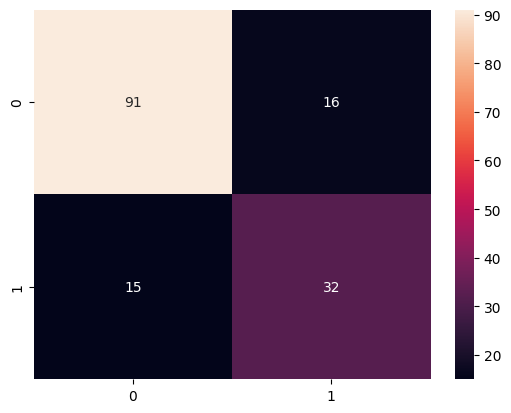

In [ ]:
# Gradient boosting normalized

GB_norm = GradientBoostingClassifier()
GB_norm.fit(X_train, Y_train)

yGBpredicted_norm = GB_norm.predict(X_test)

cmGB_norm = confusion_matrix(y_test, yGBpredicted_norm)
print('Confusion Matrix (Gradient Boosting with Normalization):')
print(cmGB_norm)
sns.heatmap(cmGB_norm, annot=True)


In [ ]:

print('\nClassification Report (Gradient Boosting with Normalization):')
print(classification_report(y_test, yGBpredicted_norm))

print('\nAccuracy (Gradient Boosting with Normalization):', accuracy_score(y_test, yGBpredicted_norm))
F1_GB_norm = f1_score(y_test, yGBpredicted_norm, average='weighted')
print('F1_score (Gradient Boosting with Normalization):', F1_GB_norm)


Classification Report (Gradient Boosting with Normalization):


'              precision    recall  f1-score   support\n\n           0       0.86      0.85      0.85       107\n           1       0.67      0.68      0.67        47\n\n    accuracy                           0.80       154\n   macro avg       0.76      0.77      0.76       154\nweighted avg       0.80      0.80      0.80       154\n'


Accuracy (Gradient Boosting with Normalization): 0.7987012987012987
F1_score (Gradient Boosting with Normalization): 0.7992882333875662


In [ ]:
models_norm = ['Logistic Regression', 'SVM','Decision Tree','KNN','Random Forest','Gradient boosted tree']
F1_score_norm = [F1_LogisticRegression_norm, F1_svm_norm, F1_tree_norm, F1_KNN_norm, F1_RandomForest_norm, F1_GB_norm]
compare_models_norm = pd.DataFrame({ 'Algorithms': models_norm, 'F1 Score (MinMax Normalized)': F1_score_norm })
print('Comparison of F1 Scores with MinMax Normalization:')
display(compare_models_norm.sort_values(by = 'F1 Score (MinMax Normalized)', ascending = True))

Comparison of F1 Scores with MinMax Normalization:


,Algorithms,F1 Score (MinMax Normalized)
2,Decision Tree,0.715914
1,SVM,0.782520
0,Logistic Regression,0.797948
3,KNN,0.797948
5,Gradient boosted tree,0.799288
4,Random Forest,0.803979


In [ ]:
combined_F1_scores = pd.merge(compare_models, compare_models_norm, on='Algorithms', how='left')
print('\nCombined F1 Scores Comparison (StandardScaler vs. MinMax Normalization):')
display(combined_F1_scores.sort_values(by = 'F1 Score (MinMax Normalized)', ascending = True))


Combined F1 Scores Comparison (StandardScaler vs. MinMax Normalization):


,Algorithms,F1 Score (Standard Scaled),F1 Score (MinMax Normalized)
2,Decision Tree,0.718736,0.715914
1,SVM,0.710898,0.782520
0,Logistic Regression,0.805519,0.797948
3,KNN,0.805519,0.797948
5,Gradient boosted tree,0.799288,0.799288
4,Random Forest,0.803979,0.803979


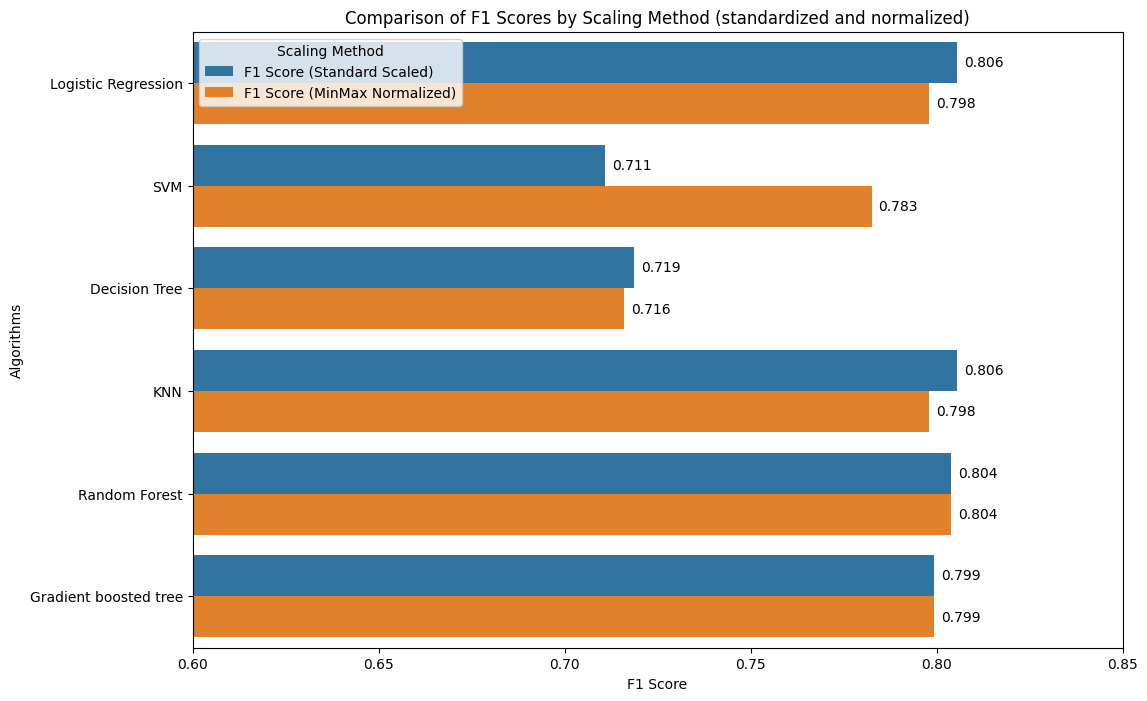

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='F1 Score Value', y='Algorithms', data=combined_F1_scores.melt(id_vars='Algorithms', value_vars=['F1 Score (Standard Scaled)', 'F1 Score (MinMax Normalized)'], var_name='Scaling Method', value_name='F1 Score Value'), hue='Scaling Method')
plt.title('Comparison of F1 Scores by Scaling Method (standardized and normalized)')
plt.xlabel('F1 Score')
plt.ylabel('Algorithms')
plt.xlim(0.6, 0.85) # Adjust x-axis limits for better visualization

ax = plt.gca()
for container in ax.containers:
    for patch in container.patches:
        width = patch.get_width()
        if width > 0: # Only annotate if there's a bar
            ax.annotate(f'{width:.3f}',
                        xy=(width, patch.get_y() + patch.get_height() / 2),
                        xytext=(5, 0),  # 5 points horizontal offset
                        textcoords="offset points",
                        ha='left', va='center')

plt.show()

### Performance Ranking (Best to Worst)

| Algorithm             | Best F1 Score |
| :-------------------- | :------------ |
| Logistic Regression   | 0.805         |
| KNN                   | 0.805         |
| Random Forest         | 0.804         |
| Gradient Boosted Tree | 0.799         |
| SVM                   | 0.783         |
| Decision Tree         | 0.719         |

*Note: The 'Best F1 Score' for each algorithm is the higher value obtained from either Standard Scaled or MinMax Normalized preprocessing.*

# ***NOTES***
What I noticed,
scaling doesnt matter for tree based model as gradient boosted tree and random forest have same normalized and standardized Decision trees make splits based on "greater than" or "less than" logic.

Scaling is crucial SVM, The SVM "Support Vector Machine" shows the biggest jump in performance from Normalized (0.78) to Standard (0.71)

KNN and Logistic Regression (when Standard Scaled) are tied for the highest F1 score at 0.8055.

They both performed slightly better with Standardization than they did with Normalization.